In [1]:
%load_ext autoreload
%autoreload 2
from eeg_toolkit import (
    load_config,
    get_eeg_channels,
    build_adjacency,
    load_band_data,
    run_cluster_test,
    describe_clusters,
    plot_cluster_results,
)
cfg = load_config('../../configs/eye_eeg_simul.yaml')
cfg_tfr = load_config('../../configs/tfr_analysis.yaml')
print("Setup OK")

Setup OK


In [23]:
eeg_channels = get_eeg_channels(cfg, cfg_tfr, "trial")
print(f"EEG channels: {len(eeg_channels)}")

[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']
EEG channels: 32


In [25]:
alpha_data, times, subjects = load_band_data(
    cfg, cfg_tfr, "trial",
    freq_band=(8, 13),
    eeg_channels=eeg_channels,
    tmin=-0.2, tmax=5,
)
adjacency = build_adjacency(eeg_channels, len(times))

[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']
Loaded 30 subjects × 2 conditions, shape per condition: (30, 32, 666)
Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 32
Adjacency: 32 channels × 666 time points = 21312 nodes


In [26]:
alpha_results = run_cluster_test(
    alpha_data["spatial"], alpha_data["symbolic"],
    adjacency,
    label="Alpha: Spatial vs Symbolic [cue]",
    n_permutations=1024,
)
describe_clusters(alpha_results, eeg_channels, times)

Running: Alpha: Spatial vs Symbolic [cue]
  30 subjects, threshold t=2.05, 1024 permutations, tail=0
  Found 125 clusters, 0 significant (p < 0.05)

CLUSTERS: Alpha: Spatial vs Symbolic [cue]
No significant clusters


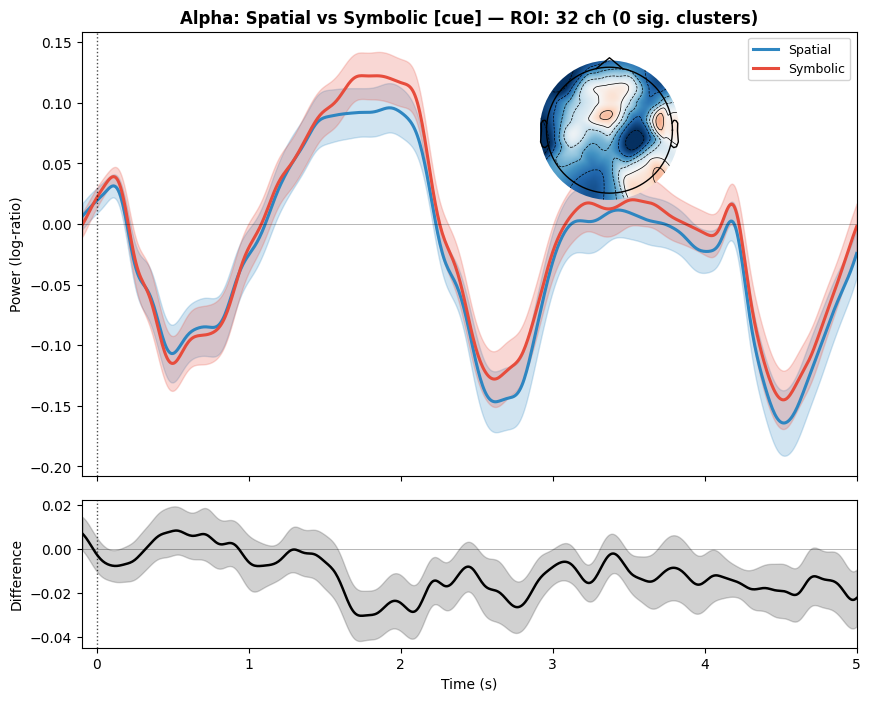

In [28]:
plot_cluster_results(
    alpha_data["spatial"], alpha_data["symbolic"],
    alpha_results, eeg_channels, times,
    label_a="Spatial", label_b="Symbolic",
    tmin=-0.1, tmax=5,
);

[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']
Loaded 30 subjects × 2 conditions, shape per condition: (30, 32, 666)
Running: Theta: Spatial vs Symbolic [cue]
  30 subjects, threshold t=2.05, 1024 permutations, tail=0
  Found 178 clusters, 0 significant (p < 0.05)

CLUSTERS: Theta: Spatial vs Symbolic [cue]
No significant clusters


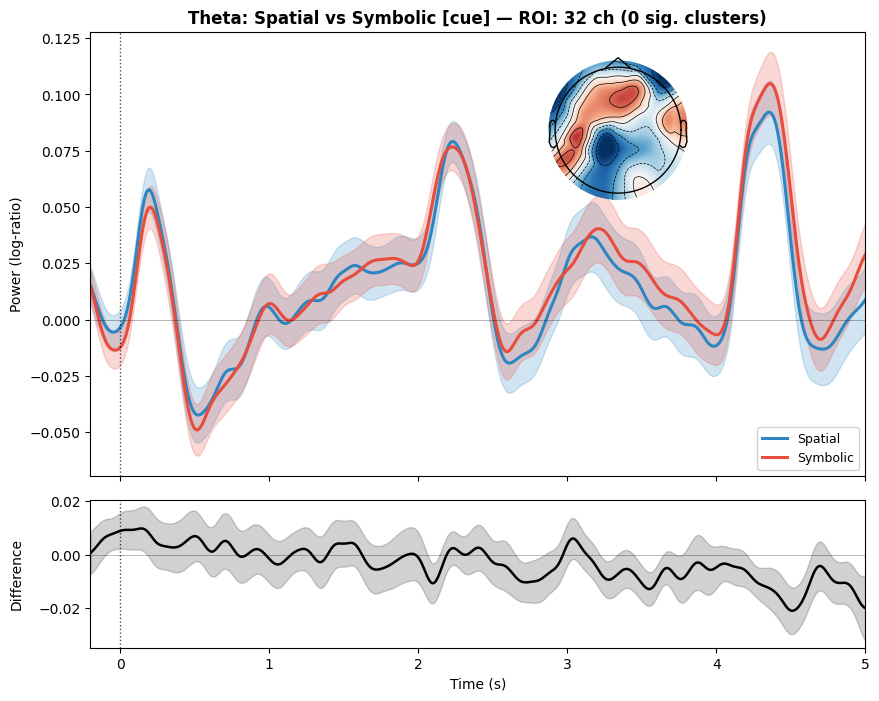

In [30]:
theta_data, times_t, _ = load_band_data(
    cfg, cfg_tfr, "trial",
    freq_band=(4, 8),
    eeg_channels=eeg_channels,
    tmin=-0.2, tmax=5,
)
theta_results = run_cluster_test(
    theta_data["spatial"], theta_data["symbolic"],
    adjacency,
    label="Theta: Spatial vs Symbolic [cue]",
    n_permutations=1024,
)
describe_clusters(theta_results, eeg_channels, times_t)
plot_cluster_results(
    theta_data["spatial"], theta_data["symbolic"],
    theta_results, eeg_channels, times_t,
    label_a="Spatial", label_b="Symbolic",
    tmin=-0.2, tmax=5,

);